# Load Data - Calculate Average IMD Scores

In [36]:
from prepare_boroughs import prepare_grouped_boroughs
from sklearn.linear_model import BayesianRidge
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
borough_df = prepare_grouped_boroughs()

DataFrame Cleaned Successfully...
>>> Columns:
['LA_2023', 'LA_Name', 'year', 'MEMS7_ALL', 'IMD_mean', 'LondInOut']
>>> Shape (224, 6)


In [64]:
train = borough_df[borough_df['year'].isin(['2016/17', '2017/18', '2018/19', '2019/20', '2020/21', '2021/22'])].copy()
test = borough_df[borough_df['year'] == '2022/23'].copy()
train['t'] = train.year.str.split('/').str[0].astype(int) - 2016
test['t'] = test.year.str.split('/').str[0].astype(int) - 2016
future_t = np.array([6, 7, 8, 9, 10, 11]).reshape(-1, 1)

# Initial Borough Forecasts

In [66]:
results = []

for borough in train.LA_Name.unique():
    X_train = train[train['LA_Name'] == borough]['t']
    y_train = train[train['LA_Name'] == borough]['MEMS7_ALL']
    X_test = test[test['LA_Name'] == borough]['t']

    X_train = X_train.values.reshape(-1, 1)
    X_test = X_test.values.reshape(1, 1)
    
    model = BayesianRidge()
    model.fit(X_train, y_train)

    y_pred, y_std = model.predict(X_test, return_std=True)
    
    results.append([borough, y_pred[0], y_std[0], model.coef_[0]])

results_df = pd.DataFrame(results, columns=['borough', 'predicted activity levels 22/23', 'uncertainty', 'gradient'])
results_df = pd.merge(results_df, test[['LA_Name', 'MEMS7_ALL']], left_on='borough', right_on='LA_Name')
results_df['mape'] = abs((results_df['MEMS7_ALL'] - results_df['predicted activity levels 22/23']) / results_df['MEMS7_ALL']) * 100
print(' mape: ', results_df['mape'].mean())

 mape:  7.097851140860188


In [70]:
forecast = []

for borough in train.LA_Name.unique():
    X_train = train[train['LA_Name'] == borough]['t']
    y_train = train[train['LA_Name'] == borough]['MEMS7_ALL']
    X_test = test[test['LA_Name'] == borough]['t']

    X_train = X_train.values.reshape(-1, 1)
    X_test = X_test.values.reshape(1, 1)
    
    model = BayesianRidge()
    model.fit(X_train, y_train)

    y_pred, y_std = model.predict(future_t, return_std=True)
    
    for i, (pred, std) in enumerate(zip(y_pred, y_std)): 
        forecast.append([borough, future_t[i][0], pred, std])

forecast_df = pd.DataFrame(forecast, columns=['borough', 't', 'y_pred', 'y_std'])
print(forecast_df.head())

                borough   t      y_pred      y_std
0  Barking and Dagenham   6  601.549575  45.660323
1  Barking and Dagenham   7  601.550009  45.662386
2  Barking and Dagenham   8  601.550442  45.664766
3  Barking and Dagenham   9  601.550875  45.667464
4  Barking and Dagenham  10  601.551309  45.670479


In [77]:
hist_df = train.groupby(['LA_Name', 't'])['MEMS7_ALL'].mean().reset_index()
hist_df.rename(columns={'LA_Name': 'borough', 'MEMS7_ALL': 'y_pred'}, inplace=True)
hist_df['y_std'] = 0
hist_df['type'] = 'historical'
forecast_df['type'] = 'forecast'
combined_df = pd.concat([hist_df, forecast_df])



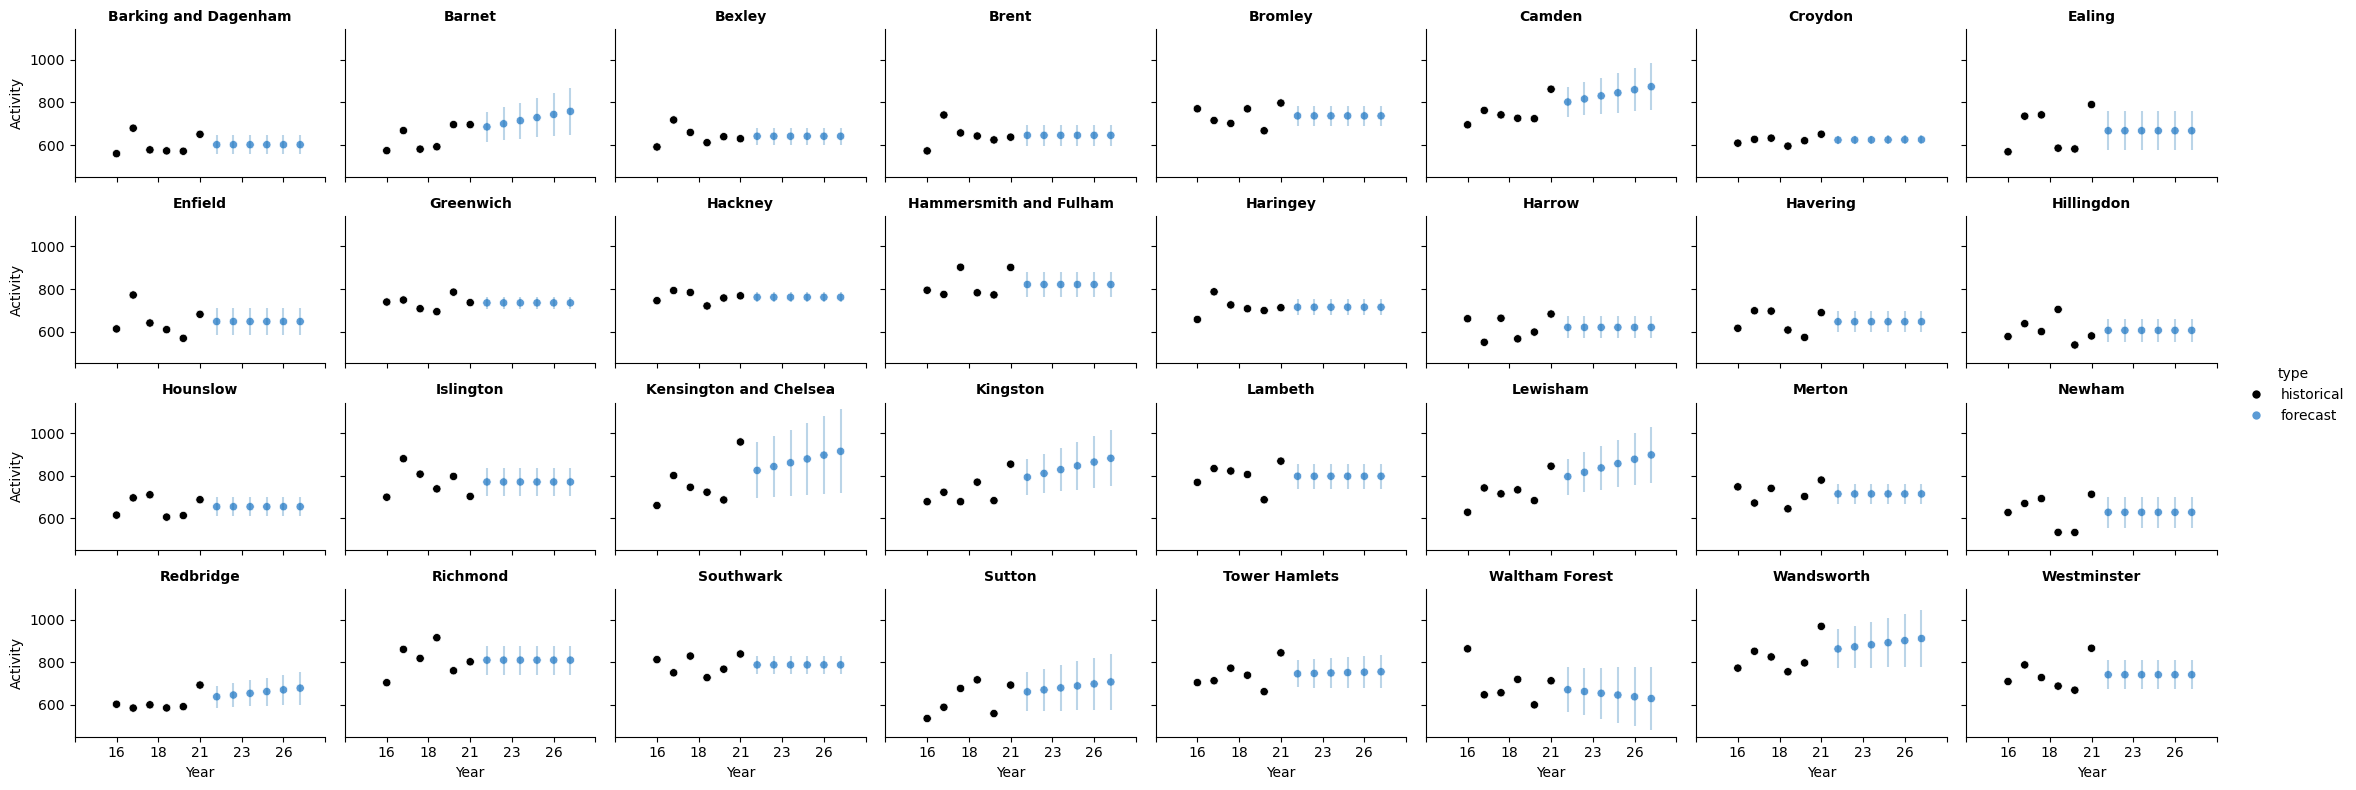

In [81]:
year_map = {0: '16', 1: '17', 2: '18', 3: '19', 4: '20', 5: '21', 6: '22', 7: '23', 8: '24', 9: '25', 10: '26', 11: '27'}
g = sns.relplot(kind='scatter', data=combined_df, x='t', y='y_pred', col='borough', col_wrap=8, height=2, aspect=1.4, hue='type', palette={'historical': 'black', 'forecast': '#5B9BD5'})
for borough, ax in g.axes_dict.items():
    borough_forecast = combined_df[combined_df['borough'] == borough]
    ax.errorbar(x=borough_forecast['t'], y=borough_forecast['y_pred'], yerr=borough_forecast['y_std'], fmt='none', alpha=0.3)
g.set_xticklabels([year_map.get(int(t), '') for t in g.axes[0].get_xticks()])
g.set_titles('{col_name}', weight='bold')
g.set(xlabel='Year', ylabel='Activity')
plt.show()

# Group Boroughs by In/Outer London + Forecast

In [76]:
forecast_zones = []

for area in train.LondInOut.unique():
    X_train = zone_train[zone_train['LondInOut'] == area]['t']
    y_train = zone_train[zone_train['LondInOut'] == area]['MEMS7_ALL']
    X_test = zone_test[zone_test['LondInOut'] == area]['t']

    X_train = X_train.values.reshape(-1, 1)
    X_test = X_test.values.reshape(-1, 1)
    
    model = BayesianRidge()
    model.fit(X_train, y_train)

    y_pred, y_std = model.predict(future_t, return_std=True)
    
    for i, (pred, std) in enumerate(zip(y_pred, y_std)): 
        forecast_zones.append([area, future_t[i][0], pred, std])

forecast_zones_df = pd.DataFrame(forecast_zones, columns=['area', 't', 'y_pred', 'y_std'])
print(forecast_zones_df.head())

    area   t      y_pred      y_std
0  Inner   6  665.972569  26.225670
1  Inner   7  665.973785  26.228554
2  Inner   8  665.975001  26.231881
3  Inner   9  665.976216  26.235651
4  Inner  10  665.977432  26.239863


In [82]:
hist_zones = zone_train.rename(columns={'LondInOut': 'area', 'MEMS7_ALL': 'y_pred'})
hist_zones['y_std'] = 0
hist_zones['type'] = 'historical'
forecast_zones_df['type'] = 'forecast'
combined_zones = pd.concat([hist_zones, forecast_zones_df])

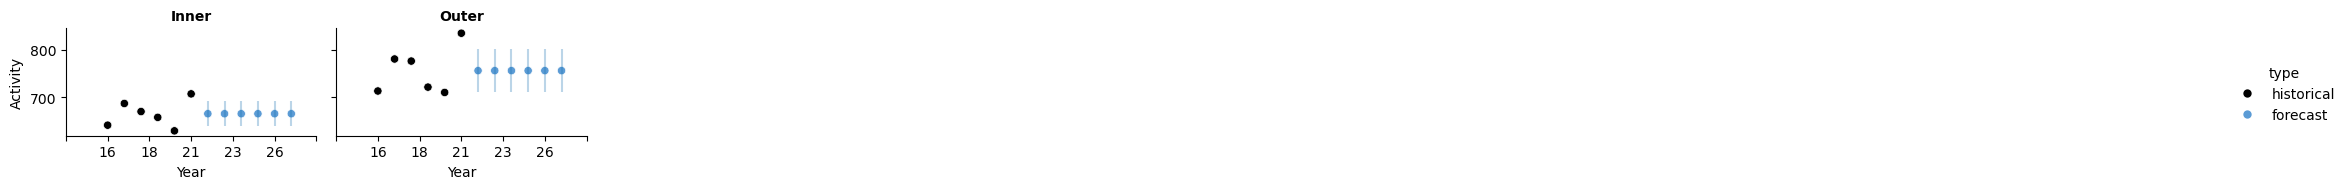

In [83]:
year_map = {0: '16', 1: '17', 2: '18', 3: '19', 4: '20', 5: '21', 6: '22', 7: '23', 8: '24', 9: '25', 10: '26', 11: '27'}
g = sns.relplot(kind='scatter', data=combined_zones, x='t', y='y_pred', col='area', col_wrap=8, height=2, aspect=1.4, hue='type', palette={'historical': 'black', 'forecast': '#5B9BD5'})
for area, ax in g.axes_dict.items():
    area_forecast = combined_zones[combined_zones['area'] == area]
    ax.errorbar(x=area_forecast['t'], y=area_forecast['y_pred'], yerr=area_forecast['y_std'], fmt='none', alpha=0.3)
g.set_xticklabels([year_map.get(int(t), '') for t in g.axes[0].get_xticks()])
g.set_titles('{col_name}', weight='bold')
g.set(xlabel='Year', ylabel='Activity')
plt.show()

# Group Boroughs by average IMD score + Forecast

In [84]:
borough_df['IMD_group'] = pd.qcut(borough_df['IMD_mean'], q=3, labels=['Low', 'Mid', 'High'])
train = train.merge(borough_df[['LA_Name', 'IMD_group']], left_on='LA_Name', right_on='LA_Name')
test = test.merge(borough_df[['LA_Name', 'IMD_group']], left_on='LA_Name', right_on='LA_Name')
imd_train = train.groupby(['IMD_group', 't'], observed=True)['MEMS7_ALL'].mean().reset_index()
imd_test = test.groupby(['IMD_group', 't'], observed=True)['MEMS7_ALL'].mean().reset_index()

forecast_imd = []

for imd in train.IMD_group.unique():
    X_train = imd_train[imd_train['IMD_group'] == imd]['t']
    y_train = imd_train[imd_train['IMD_group'] == imd]['MEMS7_ALL']
    X_test = imd_test[imd_test['IMD_group'] == imd]['t']

    X_train = X_train.values.reshape(-1, 1)
    X_test = X_test.values.reshape(-1, 1)
    
    model = BayesianRidge()
    model.fit(X_train, y_train)

    y_pred, y_std = model.predict(future_t, return_std=True)
    
    for i, (pred, std) in enumerate(zip(y_pred, y_std)): 
        forecast_imd.append([imd, future_t[i][0], pred, std])

forecast_imd_df = pd.DataFrame(forecast_imd, columns=['imd', 't', 'y_pred', 'y_std'])

/var/folders/l9/fy8m323x6318pm31w4ztftcc0000gn/T/ipykernel_2874/692614167.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  imd_train = train.groupby(['IMD_group', 't'])['MEMS7_ALL'].mean().reset_index()
/var/folders/l9/fy8m323x6318pm31w4ztftcc0000gn/T/ipykernel_2874/692614167.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  imd_test = test.groupby(['IMD_group', 't'])['MEMS7_ALL'].mean().reset_index()


In [87]:
hist_imd = imd_train.rename(columns={'IMD_group': 'imd', 'MEMS7_ALL': 'y_pred'})
hist_imd['y_std'] = 0
hist_imd['type'] = 'historical'
forecast_imd_df['type'] = 'forecast'
combined_imd = pd.concat([hist_imd, forecast_imd_df])

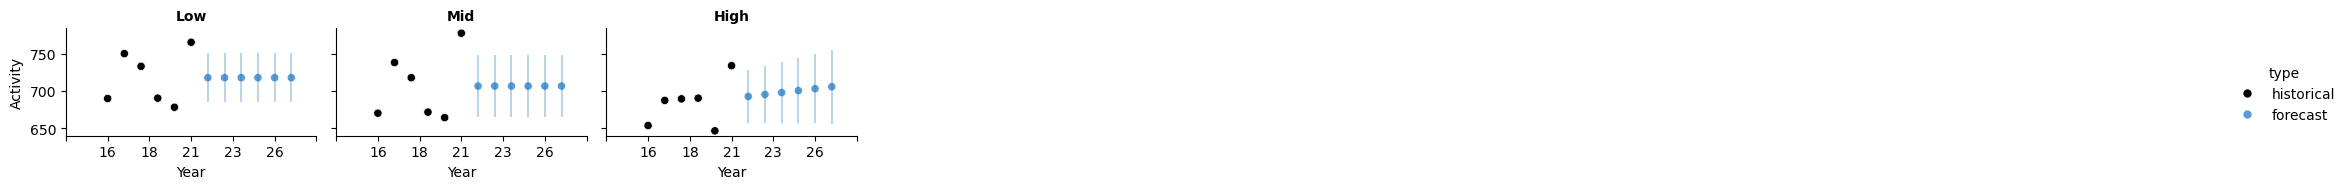

In [88]:
year_map = {0: '16', 1: '17', 2: '18', 3: '19', 4: '20', 5: '21', 6: '22', 7: '23', 8: '24', 9: '25', 10: '26', 11: '27'}
g = sns.relplot(kind='scatter', data=combined_imd, x='t', y='y_pred', col='imd', col_wrap=8, height=2, aspect=1.4, hue='type', palette={'historical': 'black', 'forecast': '#5B9BD5'})
for imd, ax in g.axes_dict.items():
    imd_forecast = combined_imd[combined_imd['imd'] == imd]
    ax.errorbar(x=imd_forecast['t'], y=imd_forecast['y_pred'], yerr=imd_forecast['y_std'], fmt='none', alpha=0.3)
g.set_xticklabels([year_map.get(int(t), '') for t in g.axes[0].get_xticks()])
g.set_titles('{col_name}', weight='bold')
g.set(xlabel='Year', ylabel='Activity')
plt.show()

# Prepare Results for Tableu Visualisation (Individual / Gradient / IMD / Zones)